In [7]:
# 0. 라이브러리 임포트 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries loaded')

# 1. 데이터 및 모델 로드
X_train = pd.read_csv('../outputs/X_train.csv')
X_test = pd.read_csv('../outputs/X_test.csv')
y_test = pd.read_csv('../outputs/y_test.csv').squeeze()

model = joblib.load('../outputs/models/xgboost_churn.pkl')

print(f'X_test shape: {X_test.shape}')
print('✅ Model loaded')

✅ Libraries loaded
X_test shape: (1106, 34)
✅ Model loaded


In [8]:
# 2. Tree SHAP 계산
# 논문: XGBoost + TreeSHAP → global/local 설명 모두 산출

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f'SHAP values shape: {shap_values.shape}')
print('✅ SHAP values computed')

SHAP values shape: (1106, 34)
✅ SHAP values computed


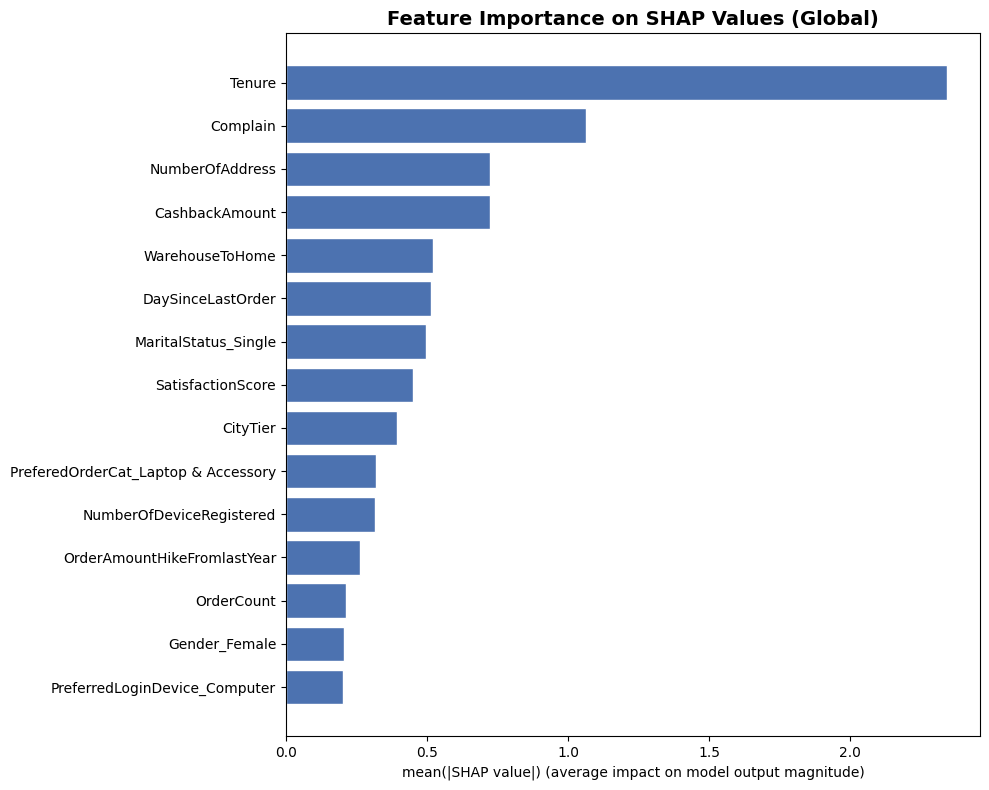


=== Top 10 Features ===
                            Feature  Importance
                             Tenure    2.343733
                           Complain    1.064590
                    NumberOfAddress    0.725201
                     CashbackAmount    0.722558
                    WarehouseToHome    0.521445
                  DaySinceLastOrder    0.515575
               MaritalStatus_Single    0.496083
                  SatisfactionScore    0.451847
                           CityTier    0.393509
PreferedOrderCat_Laptop & Accessory    0.320185


In [9]:
# 3. Global Feature Importance (Fig 1a 재현)
# 논문: mean(|SHAP|) 기준 feature importance

shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(shap_importance['Feature'][:15][::-1],
         shap_importance['Importance'][:15][::-1],
         color='#4C72B0', edgecolor='white')
plt.xlabel('mean(|SHAP value|) (average impact on model output magnitude)')
plt.title('Feature Importance on SHAP Values (Global)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/04_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Top 10 Features ===')
print(shap_importance.head(10).to_string(index=False))

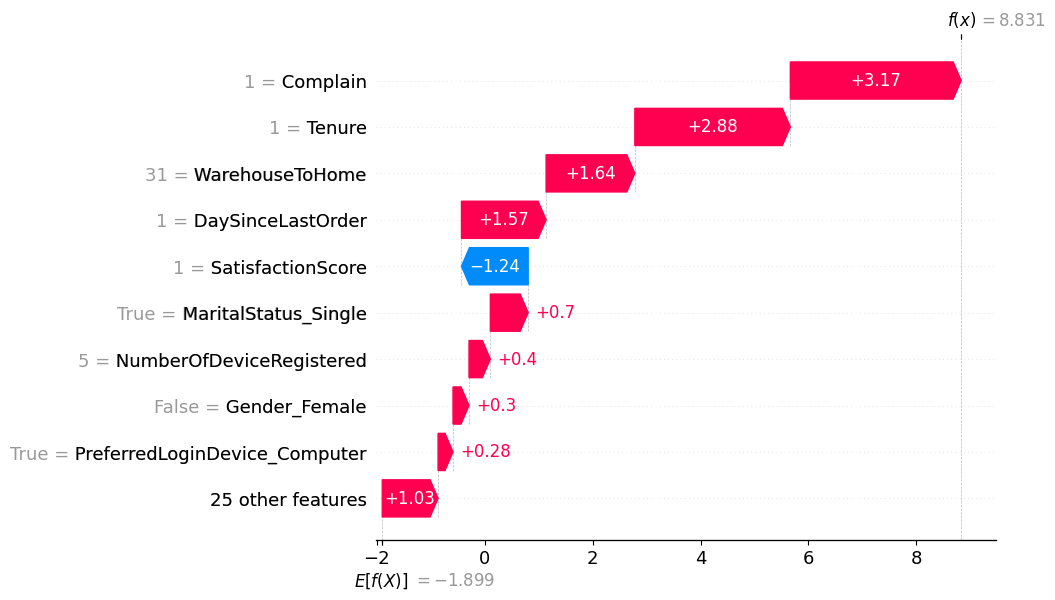

<Figure size 640x480 with 0 Axes>

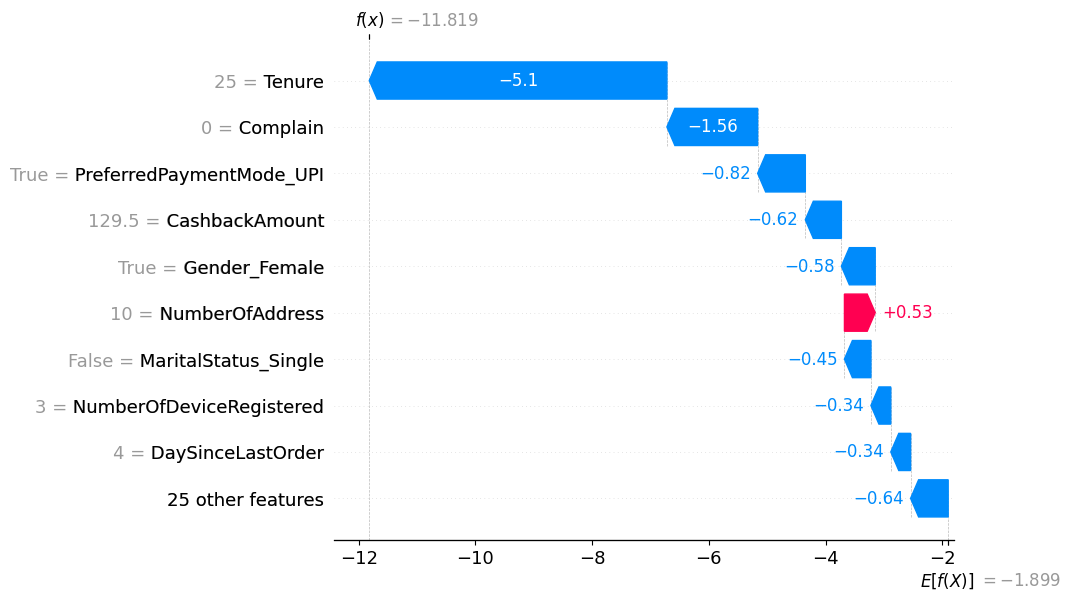

In [18]:
# 5. Local Explanation

y_pred_proba = model.predict_proba(X_test)[:, 1]
high_risk_idx = y_pred_proba.argmax()
low_risk_idx = y_pred_proba.argmin()

# High risk
plt.figure()
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[high_risk_idx],
        feature_names=X_test.columns.tolist()
    ),
    max_display=10
)
plt.savefig('../outputs/figures/04_shap_local_highrisk.png', dpi=150, bbox_inches='tight')

# Low risk
plt.figure()
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[low_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[low_risk_idx],
        feature_names=X_test.columns.tolist()
    ),
    max_display=10
)
plt.savefig('../outputs/figures/04_shap_local_lowrisk.png', dpi=150, bbox_inches='tight')

In [11]:
# 6. SHAP 해석 요약 (논문 결과 비교)
print('=' * 55)
print('📋 SHAP Analysis Summary')
print('=' * 55)
print('\n논문 주요 결과:')
print('  Tenure↑        → SHAP↓  (오래된 고객일수록 이탈 안 함)')
print('  Complain↑      → SHAP↑  (불만 접수 = 가장 큰 이탈 신호)')
print('  CashbackAmount↑→ SHAP↓  (캐시백 많을수록 이탈 방어)')
print('  DaySinceLastOrder↑→SHAP↑(마지막 주문 오래될수록 위험)')
print()
print('재현 결과 Top 5:')
print(shap_importance.head(5).to_string(index=False))
print()
print('➡️  Next: 05_survival.ipynb')

📋 SHAP Analysis Summary

논문 주요 결과:
  Tenure↑        → SHAP↓  (오래된 고객일수록 이탈 안 함)
  Complain↑      → SHAP↑  (불만 접수 = 가장 큰 이탈 신호)
  CashbackAmount↑→ SHAP↓  (캐시백 많을수록 이탈 방어)
  DaySinceLastOrder↑→SHAP↑(마지막 주문 오래될수록 위험)

재현 결과 Top 5:
        Feature  Importance
         Tenure    2.343733
       Complain    1.064590
NumberOfAddress    0.725201
 CashbackAmount    0.722558
WarehouseToHome    0.521445

➡️  Next: 05_survival.ipynb
